In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
dataset_path = '/content/drive/MyDrive/Dataset_BUSI_with_GT'

from collections import Counter

all_images = []
labels = []
for label in ['benign', 'malignant', 'normal']:
    folder = os.path.join(dataset_path, label)
    for fname in os.listdir(folder):
        if "_mask" not in fname and fname.endswith(('.png', '.jpg')):
            all_images.append(os.path.join(folder, fname))
            labels.append(label)

print("Original class distribution:", dict(Counter(labels)))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Original class distribution: {'benign': 437, 'malignant': 210, 'normal': 133}


In [ ]:
import pandas as pd
from sklearn.utils import resample

df = pd.DataFrame({'image_path': all_images, 'label': labels})

df_ben = df[df.label == 'benign']
df_mal = df[df.label == 'malignant']
df_norm = df[df.label == 'normal']

df_mal_up = resample(df_mal, replace=True, n_samples=len(df_ben), random_state=42)
df_norm_up = resample(df_norm, replace=True, n_samples=len(df_ben), random_state=42)

df_balanced = pd.concat([df_ben, df_mal_up, df_norm_up])
print("Balanced class distribution:", dict(Counter(df_balanced.label)))


Balanced class distribution: {'benign': 437, 'malignant': 437, 'normal': 437}


In [ ]:
from sklearn.model_selection import train_test_split
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

train_df, val_df = train_test_split(df_balanced, test_size=0.2, stratify=df_balanced.label, random_state=42)

label_map = {'benign': 0, 'malignant': 1, 'normal': 2}

class BUSIDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image = Image.open(self.df.loc[idx, 'image_path']).convert('RGB')
        label = label_map[self.df.loc[idx, 'label']]
        if self.transform:
            image = self.transform(image)
        return image, label

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_dataset = BUSIDataset(train_df, transform=train_transform)
val_dataset = BUSIDataset(val_df, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

class HybridCNNTransformer(nn.Module):
    def __init__(self, num_classes=3):
        super(HybridCNNTransformer, self).__init__()
        base_model = models.resnet18(pretrained=True)
        self.encoder = nn.Sequential(*list(base_model.children())[:-2])
        self.attn = nn.Sequential(
            nn.Conv2d(512, 256, 1),
            nn.ReLU(),
            nn.Conv2d(256, 1, 1),
            nn.Softmax(dim=-1)
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        features = self.encoder(x)
        attn_map = self.attn(features)
        features = features * attn_map
        pooled = self.pool(features).squeeze()
        out = self.fc(pooled)
        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HybridCNNTransformer().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
from tqdm import tqdm
import matplotlib.pyplot as plt

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

def train_one_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

def validate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

for epoch in range(10):
    print(f"\nEpoch {epoch+1}")
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = validate(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")



Epoch 1


100%|██████████| 33/33 [04:46<00:00,  8.67s/it]


Train Loss: 0.7852 | Acc: 0.7147
Val   Loss: 0.6042 | Acc: 0.7529

Epoch 2


100%|██████████| 33/33 [04:38<00:00,  8.43s/it]


Train Loss: 0.3547 | Acc: 0.8826
Val   Loss: 0.4083 | Acc: 0.8441

Epoch 3


...

Train Loss: 0.0662 | Acc: 0.9809
Val   Loss: 0.1935 | Acc: 0.9392

Epoch 9


100%|██████████| 33/33 [04:33<00:00,  8.29s/it]


Train Loss: 0.0538 | Acc: 0.9838
Val   Loss: 0.1641 | Acc: 0.9392

Epoch 10


100%|██████████| 33/33 [04:32<00:00,  8.25s/it]


Train Loss: 0.0485 | Acc: 0.9876
Val   Loss: 0.1575 | Acc: 0.9582


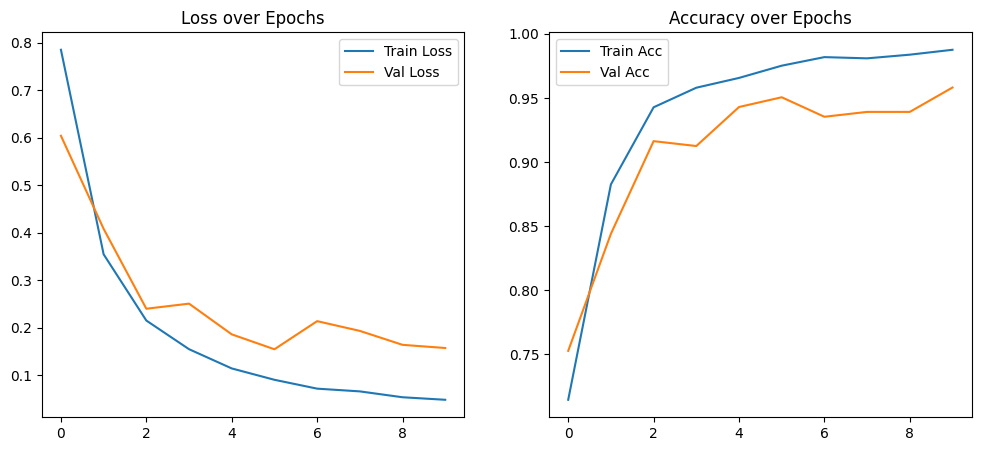

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title("Loss over Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Acc')
plt.plot(val_accuracies, label='Val Acc')
plt.title("Accuracy over Epochs")
plt.legend()

plt.show()


              precision    recall  f1-score   support

      benign       0.95      0.93      0.94        87
   malignant       1.00      0.94      0.97        88
      normal       0.93      1.00      0.96        88

    accuracy                           0.96       263
   macro avg       0.96      0.96      0.96       263
weighted avg       0.96      0.96      0.96       263



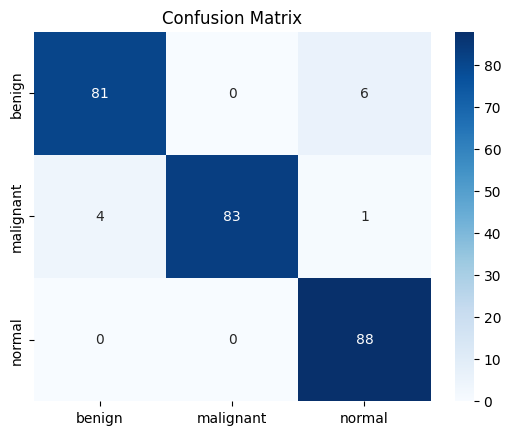

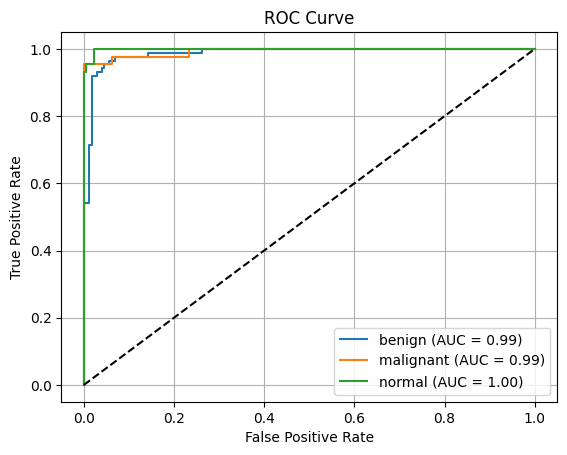

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
import numpy as np

model.eval()
all_preds, all_probs, all_labels = [], [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        all_preds += outputs.argmax(1).cpu().tolist()
        all_probs += torch.softmax(outputs, dim=1).cpu().tolist()
        all_labels += labels.tolist()

print(classification_report(all_labels, all_preds, target_names=label_map.keys()))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, cmap="Blues", xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.title("Confusion Matrix")
plt.show()

# ROC Curve
y_true_bin = label_binarize(all_labels, classes=[0, 1, 2])
y_score = np.array(all_probs)
fpr, tpr, roc_auc = {}, {}, {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

for i, label in enumerate(label_map.keys()):
    plt.plot(fpr[i], tpr[i], label=f'{label} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.legend()
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid()
plt.show()


In [ ]:
torch.save(model.state_dict(), '/content/drive/MyDrive/breast_cancer_model1.pth')
print("✅ Model saved successfully!")

correct = 0
total = 0
model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"✅ Final Validation Accuracy: {100 * correct / total:.2f}%")


✅ Model saved successfully!
✅ Final Validation Accuracy: 95.82%


In [ ]:
!pip install torchcam

In [ ]:
import torch
import torch.nn.functional as F
import cv2
import numpy as np

def score_cam(input_tensor, feature_maps, target_class):
    fmap = feature_maps[0][0]  # shape: [C, H, W]
    # Initialize cam with the same size as the feature map, but with requires_grad=False
    cam = torch.zeros(fmap.shape[1:], dtype=torch.float32, device=fmap.device, requires_grad=False)

    for i in range(fmap.shape[0]):
        feature = fmap[i, :, :].unsqueeze(0).unsqueeze(0)
        feature_resized = F.interpolate(feature, size=(224, 224), mode='bilinear', align_corners=False)
        normalized = (feature_resized - feature_resized.min()) / (feature_resized.max() - feature_resized.min() + 1e-5)

        with torch.no_grad():
            weighted_input = input_tensor * normalized
            # The model output is 1-dimensional, so we only need one index
            # Changed line: Accessing the output using only target_class as index
            score = model(weighted_input)[target_class]  # Accessing using only target_class

        # Resize normalized to match cam's size before adding
        normalized_resized = F.interpolate(normalized, size=cam.shape, mode='bilinear', align_corners=False)
        cam += score.item() * normalized_resized.squeeze()

    # Detach the cam tensor from the computation graph before converting to NumPy
    cam = cam.detach().cpu().numpy()
    cam = np.maximum(cam, 0)
    cam = cam / cam.max()
    cam = cv2.resize(cam, (224, 224))

    return cam

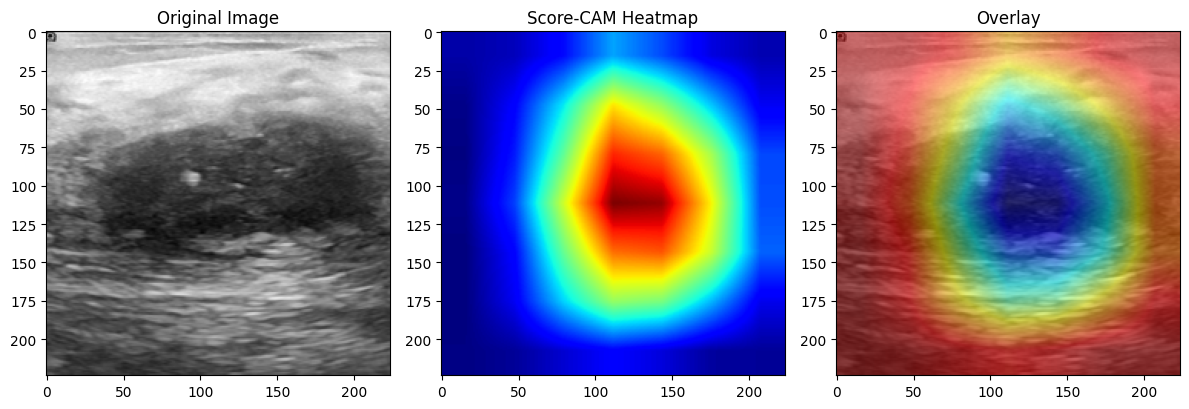

In [ ]:
import torch
import torch.nn.functional as F
import cv2
import numpy as np
from PIL import Image
from torchvision import transforms

# Assuming 'model', 'val_transform', and 'device' are defined

# Load sample image and preprocess
img_path = '/content/drive/MyDrive/Dataset_BUSI_with_GT/malignant/malignant (1).png'  # Replace as needed
image = Image.open(img_path).convert("RGB")
input_tensor = val_transform(image).unsqueeze(0).to(device)

# Hook to extract feature maps
activations = []

def forward_hook(module, input, output):
    activations.append(output.detach())

# Register the hook to the desired layer
target_layer = model.encoder[-1]  # Replace with your target layer
hook_handle = target_layer.register_forward_hook(forward_hook)

# Forward pass to get the prediction and feature maps
with torch.no_grad():
    output = model(input_tensor)
    pred_class = output.argmax().item()  # Get predicted class

# Get feature maps and remove the hook
feature_maps = activations
hook_handle.remove()

# Generate Score-CAM heatmap
cam_map = score_cam(input_tensor, feature_maps, pred_class)

# Overlay CAM on image
image_np = np.array(image.resize((224, 224))) / 255.0
heatmap = cv2.applyColorMap(np.uint8(255 * cam_map), cv2.COLORMAP_JET)
heatmap = np.float32(heatmap) / 255
overlay = heatmap + image_np
overlay = overlay / np.max(overlay)

# Plot result
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(image_np)
plt.title("Original Image")

plt.subplot(1, 3, 2)
plt.imshow(cam_map, cmap='jet')
plt.title("Score-CAM Heatmap")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Overlay")

plt.tight_layout()
plt.show()

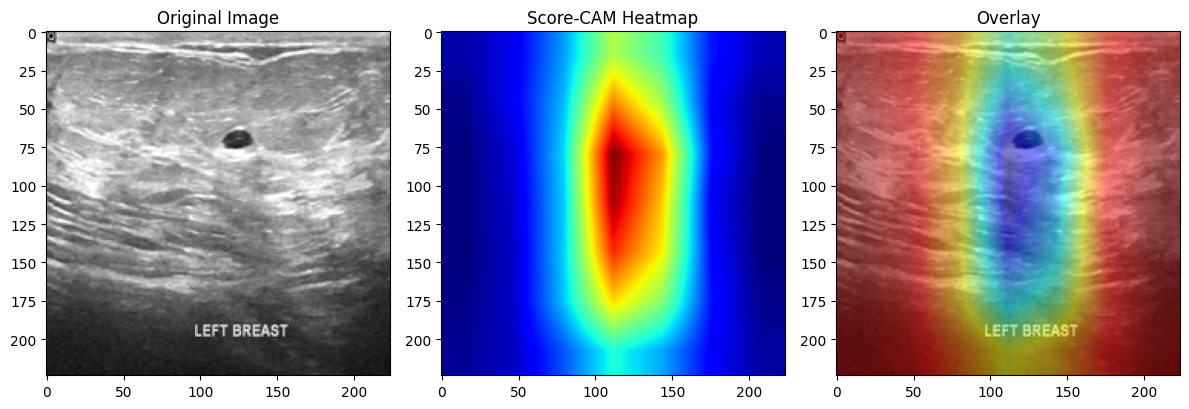

In [ ]:
import torch
import torch.nn.functional as F
import cv2
import numpy as np
from PIL import Image
from torchvision import transforms

# Assuming 'model', 'val_transform', and 'device' are defined

# Load sample image and preprocess
img_path = '/content/drive/MyDrive/Dataset_BUSI_with_GT/benign/benign (1).png'  # Replace as needed
image = Image.open(img_path).convert("RGB")
input_tensor = val_transform(image).unsqueeze(0).to(device)

# Hook to extract feature maps
activations = []

def forward_hook(module, input, output):
    activations.append(output.detach())

# Register the hook to the desired layer
target_layer = model.encoder[-1]  # Replace with your target layer
hook_handle = target_layer.register_forward_hook(forward_hook)

# Forward pass to get the prediction and feature maps
with torch.no_grad():
    output = model(input_tensor)
    pred_class = output.argmax().item()  # Get predicted class

# Get feature maps and remove the hook
feature_maps = activations
hook_handle.remove()

# Generate Score-CAM heatmap
cam_map = score_cam(input_tensor, feature_maps, pred_class)

# Overlay CAM on image
image_np = np.array(image.resize((224, 224))) / 255.0
heatmap = cv2.applyColorMap(np.uint8(255 * cam_map), cv2.COLORMAP_JET)
heatmap = np.float32(heatmap) / 255
overlay = heatmap + image_np
overlay = overlay / np.max(overlay)

# Plot result
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(image_np)
plt.title("Original Image")

plt.subplot(1, 3, 2)
plt.imshow(cam_map, cmap='jet')
plt.title("Score-CAM Heatmap")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Overlay")

plt.tight_layout()
plt.show()

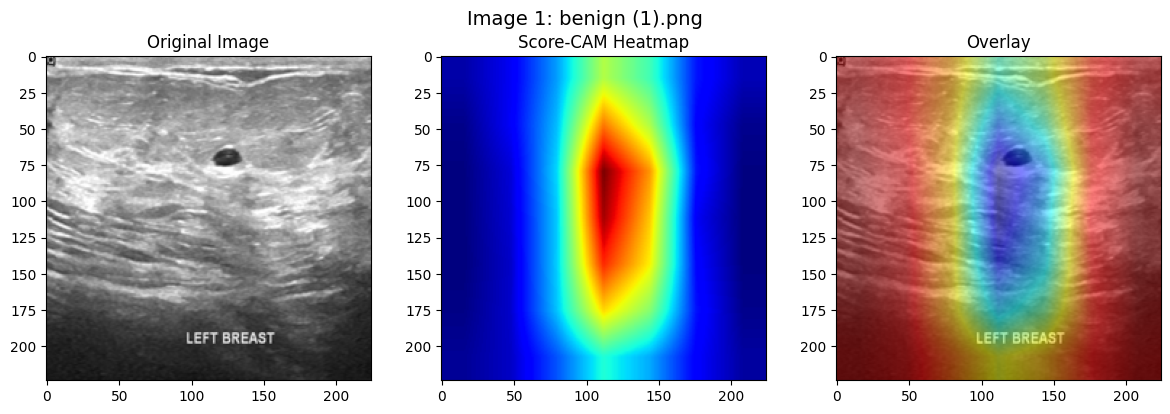

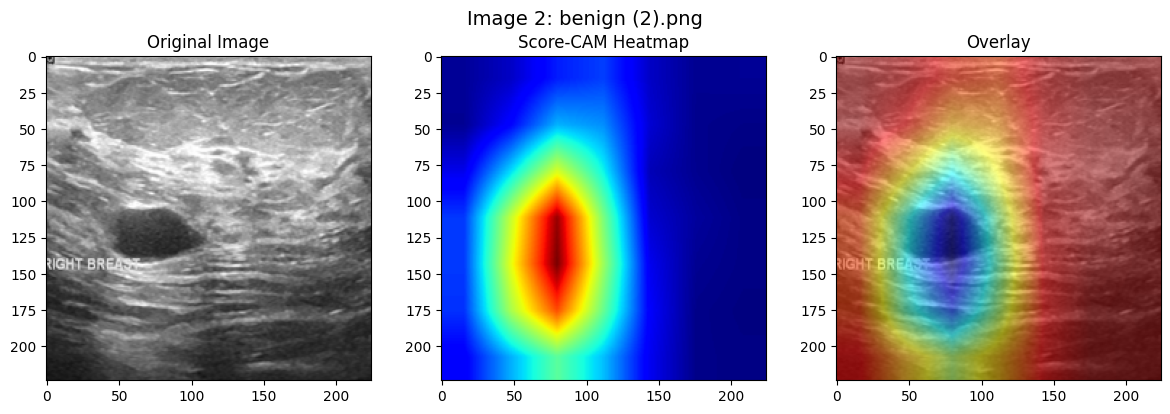

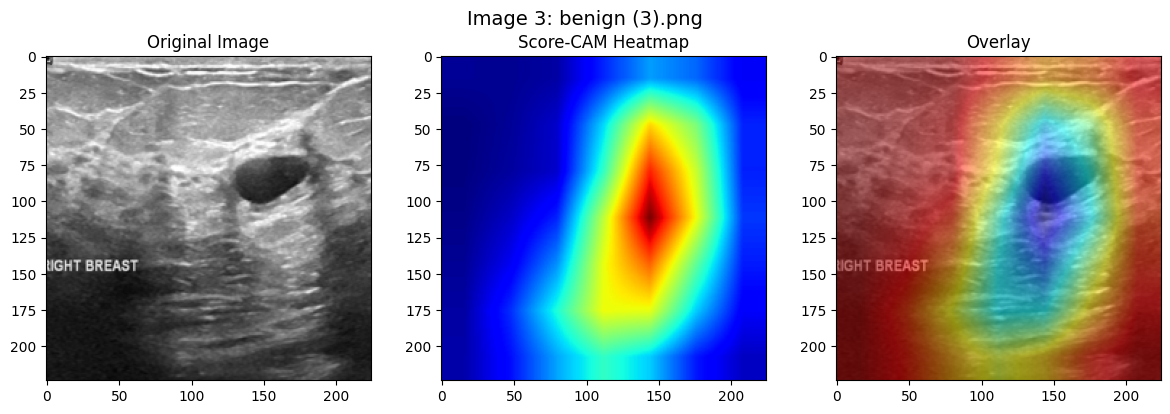

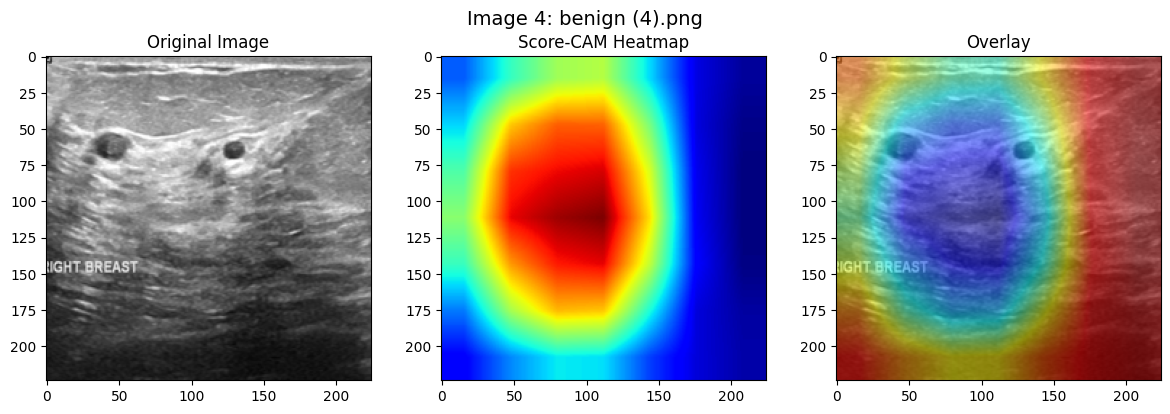

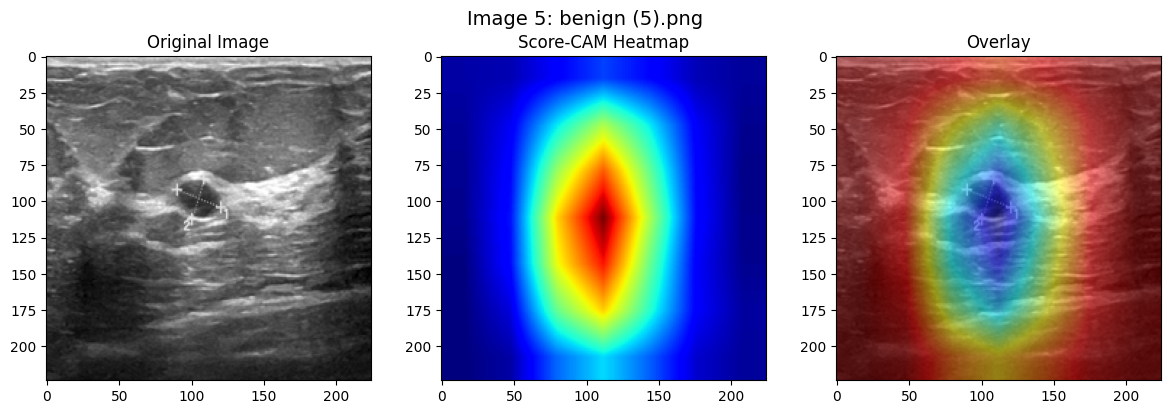

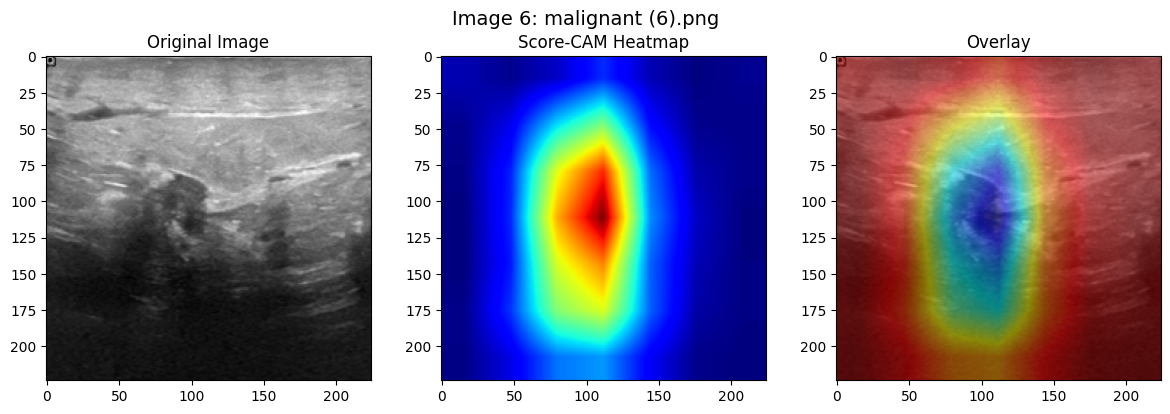

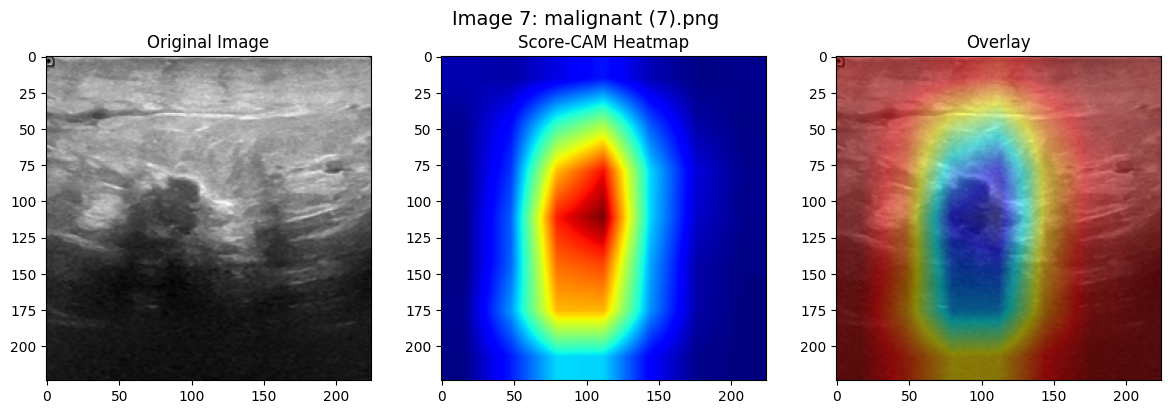

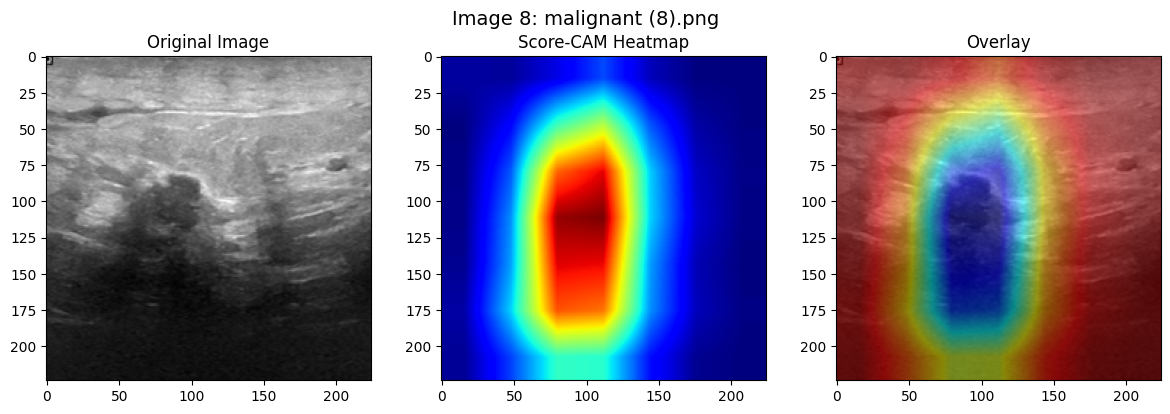

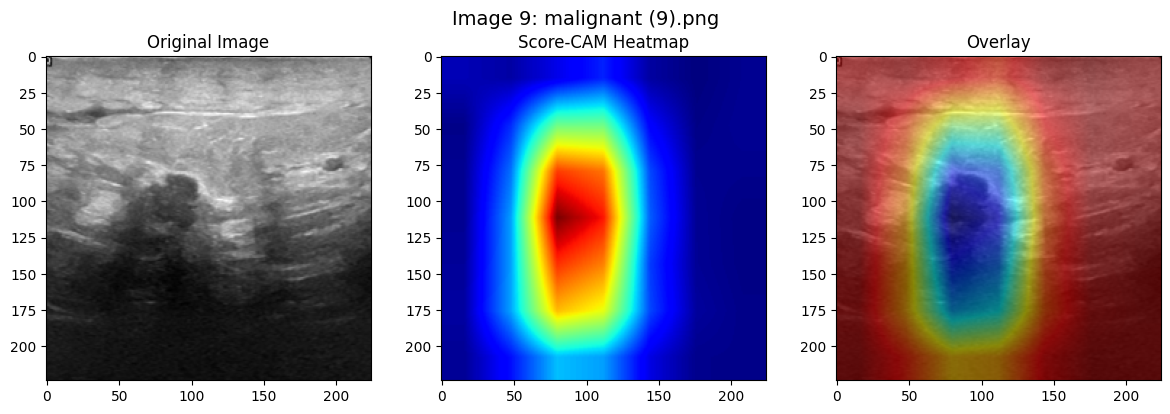

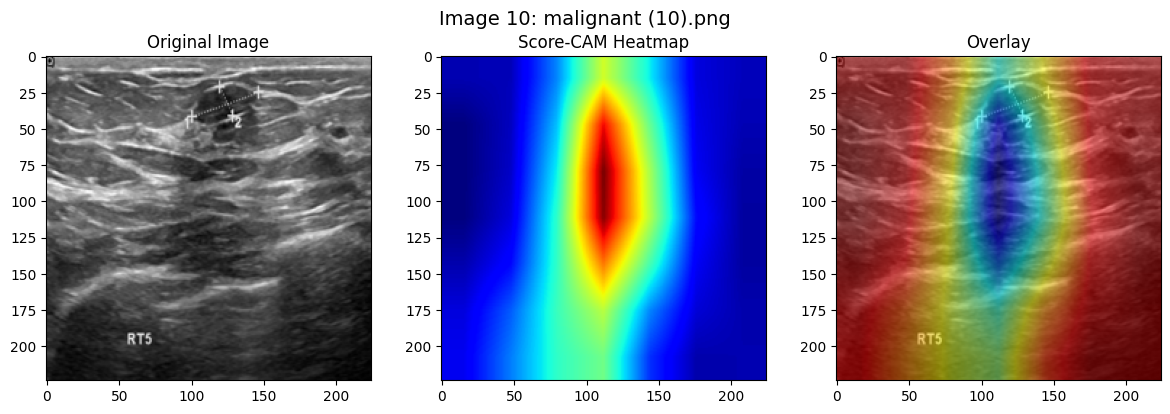

<ipython-input-38-f1ac08607c6b>:29: RuntimeWarning: invalid value encountered in divide
  cam = cam / cam.max()
<ipython-input-42-fabdf4818a0d>:54: RuntimeWarning: invalid value encountered in cast
  heatmap = cv2.applyColorMap(np.uint8(255 * cam_map), cv2.COLORMAP_JET)


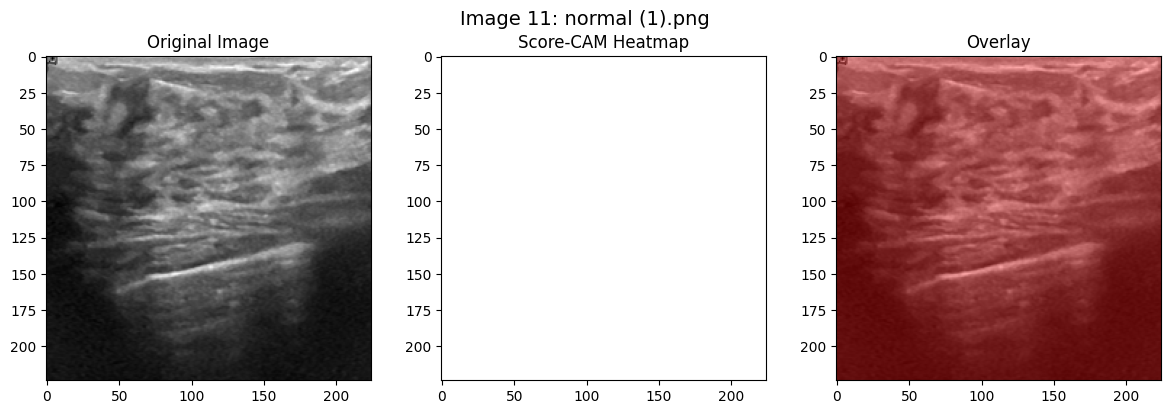

In [ ]:
import torch
import torch.nn.functional as F
import cv2
import numpy as np
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import os

# === Setup ===
# Assume model, val_transform, device, score_cam are already defined
image_paths = [
    '/content/drive/MyDrive/Dataset_BUSI_with_GT/benign/benign (1).png',
    '/content/drive/MyDrive/Dataset_BUSI_with_GT/benign/benign (2).png',
    '/content/drive/MyDrive/Dataset_BUSI_with_GT/benign/benign (3).png',
    '/content/drive/MyDrive/Dataset_BUSI_with_GT/benign/benign (4).png',
    '/content/drive/MyDrive/Dataset_BUSI_with_GT/benign/benign (5).png',
    '/content/drive/MyDrive/Dataset_BUSI_with_GT/malignant/malignant (6).png',
    '/content/drive/MyDrive/Dataset_BUSI_with_GT/malignant/malignant (7).png',
    '/content/drive/MyDrive/Dataset_BUSI_with_GT/malignant/malignant (8).png',
    '/content/drive/MyDrive/Dataset_BUSI_with_GT/malignant/malignant (9).png',
    '/content/drive/MyDrive/Dataset_BUSI_with_GT/malignant/malignant (10).png',
    '/content/drive/MyDrive/Dataset_BUSI_with_GT/normal/normal (1).png'
]

# === Hook Setup ===
activations = []

def forward_hook(module, input, output):
    activations.append(output.detach())

target_layer = model.encoder[-1]  # Change according to your model
hook_handle = target_layer.register_forward_hook(forward_hook)

# === Process and visualize ===
for i, img_path in enumerate(image_paths):
    activations.clear()

    # Load and preprocess image
    image = Image.open(img_path).convert("RGB")
    input_tensor = val_transform(image).unsqueeze(0).to(device)

    # Forward pass
    with torch.no_grad():
        output = model(input_tensor)
        pred_class = output.argmax().item()

    # Extract activations
    feature_maps = activations
    cam_map = score_cam(input_tensor, feature_maps, pred_class)

    # Prepare overlay
    image_np = np.array(image.resize((224, 224))) / 255.0
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_map), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    overlay = heatmap + image_np
    overlay = overlay / np.max(overlay)

    # Plot results
    plt.figure(figsize=(12, 4))
    plt.suptitle(f"Image {i+1}: {os.path.basename(img_path)}", fontsize=14)

    plt.subplot(1, 3, 1)
    plt.imshow(image_np)
    plt.title("Original Image")

    plt.subplot(1, 3, 2)
    plt.imshow(cam_map, cmap='jet')
    plt.title("Score-CAM Heatmap")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Overlay")

    plt.tight_layout()
    plt.show()

# Remove hook after processing
hook_handle.remove()
